In [1]:
from typing import Any
import os
import re

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

## **STAR team part**

**PART 1:** A surface code is a type of quantum error-correcting stabilizer code. A "distance-3" ($d=3$) surface code is designed to reliably detect and correct any single physical error that occurs anywhere on the grid without the logical qubit failing. 

To build this logical processor, we use **17 physical qubits** arranged in a planar square lattice:
*   **9 Data Qubits:** These hold the actual logical quantum state and are never measured directly during the computation cycle. 
*   **8 Ancilla (Measure) Qubits:** These act as "watchdogs." They are interlaced with the data qubits and are continuously measured to extract error syndromes without destroying the underlying data.

Geometry & Qubit Mapping

To build the circuit in Tsim, we map the qubits across a 2D grid. The data qubits form a $3 \times 3$ lattice, while the ancillas sit between them to measure "plaquettes" (groups of 2 or 4 adjacent data qubits). 

**Our 17-Qubit Map:**
*   **Data (0-8):** Vertices of the grid.
*   **Z-Ancillas (9-12):** Measure $Z$-parity.
*   **X-Ancillas (13-16):** Measure $X$-parity.


**Stabilizer Checks (The X and Z Crosses)**

We detect errors by measuring multi-qubit Pauli operators called "stabilizers".  

- Z-Stabilizers (Green Checks): These entangle a Z-ancilla with its neighboring data qubits. Measuring the Z-ancilla allows us to detect X (bit-flip) errors on those data qubits.  

- X-Stabilizers (Yellow Checks): These entangle an X-ancilla with its neighbors. Using a Hadamard gate to change the basis, measuring the X-ancilla allows us to detect Z (phase-flip) errors.  

**Syndrome Extraction Over Time**
  

A single round of measurements is not reliable because the measurement hardware itself might introduce errors. To achieve fault tolerance, we perform repeated syndrome extraction cycles.  

1. Initialize the ancillas.

2. Entangle them with data qubits (using a strict CNOT schedule to avoid gate collisions).

3. Measure the ancillas.

4. Repeat.

By running this circuit for several rounds, we track the errors over time, transforming the problem from a 2D spatial grid into a 3D volume (2D space + 1D time). Tracking these measurements over multiple rounds is essential to distinguish between genuine data qubit errors and faulty measurement events. In Tsim, "Detectors" compare the measurement of an ancilla in the current round to its measurement in the previous round—if the parity suddenly flips, the detector fires, indicating an error occurred in that specific time window.

In [2]:
from bloqade import squin, tsim
from bloqade.types import Qubit
from kirin.dialects.ilist import IList
from typing import Any

Register = IList[Qubit, Any]

@squin.kernel
def d3_surface_code() -> Register:
    # Allocate all 17 physical qubits symmetrically:
    data = squin.qalloc(9)      # Indices 0-8
    z_anc = squin.qalloc(4)     # Indices 0-3
    x_anc = squin.qalloc(4)     # Indices 0-3
    
    # Execute 2 rounds of syndrome extraction
    for r in range(2):
        squin.broadcast.h(x_anc)
            
        # 4-layer CNOT Schedule
        # Z-checks: Data is control, Ancilla is target
        # X-checks: Ancilla is control, Data is target
        
        # Layer 1: North Interactions
        squin.cx(data[0], z_anc[0])  
        squin.cx(data[4], z_anc[3]) 
        squin.cx(data[2], z_anc[1])
        squin.cx(x_anc[1], data[1])
        squin.cx(x_anc[2], data[3])
        squin.cx(x_anc[3], data[7])
        
        # Layer 2: East Interactions
        squin.cx(data[1], z_anc[0])
        squin.cx(data[3], z_anc[2])
        squin.cx(data[5], z_anc[3])
        squin.cx(x_anc[1], data[2])
        squin.cx(x_anc[2], data[4])
        squin.cx(x_anc[3], data[8])
        
        # Layer 3: West Interactions
        squin.cx(data[3], z_anc[0])
        squin.cx(data[7], z_anc[3])
        squin.cx(data[5], z_anc[1])
        squin.cx(x_anc[2], data[6])
        squin.cx(x_anc[1], data[4])
        squin.cx(x_anc[0], data[0])
        
        # Layer 4: South Interactions
        squin.cx(data[4], z_anc[0])
        squin.cx(data[6], z_anc[2])
        squin.cx(data[8], z_anc[3])
        squin.cx(x_anc[0], data[1])
        squin.cx(x_anc[2], data[7])
        squin.cx(x_anc[1], data[5])
        
        squin.broadcast.h(x_anc)
            
        # Mid-circuit measurement of the watchdogs
        squin.broadcast.measure(z_anc)
        squin.broadcast.measure(x_anc)

        # Reset ancillas
        squin.broadcast.reset(z_anc)
        squin.broadcast.reset(x_anc)

        # Check if there are errors:
        if r == 0: squin.x(data[4])
        
    return data

In [23]:
show_circuit(d3_surface_code)

An error is defined as a change in parity over time.

In [3]:
def analyze_syndrome_extraction(results):
    """    
    Args:
        results: A 2D numpy array of shape (shots, 16) from the Tsim sampler.
        
    Returns:
        A list of dictionaries containing the parsed Z and X error vectors for each shot.
    """
    parsed_data = []
    
    for shot_idx, raw_shot in enumerate(results):
        print(f"\n=========================================")
        print(f" SHOT {shot_idx + 1} ANALYSIS")
        print(f"=========================================")
        
        # Reshape the 16 bits into a 2D matrix: (2 Rounds, 8 Ancillas)
        measurements_by_round = raw_shot.reshape((2, 8))
        
        z_meas = measurements_by_round[:, 0:4]
        x_meas = measurements_by_round[:, 4:8]
        
        # Did the parity change between rounds?
        # We use XOR (^) to find differences. True ^ False = True (Error!)
        z_errors = z_meas[1] ^ z_meas[0]
        x_errors = x_meas[1] ^ x_meas[0]
        
        print("RAW MEASUREMENTS (Round 1 -> Round 2):")
        print(f"Z-Ancillas: {z_meas[0]} -> {z_meas[1]}")
        print(f"X-Ancillas: {x_meas[0]} -> {x_meas[1]}\n")
        
        print("DETECTOR VECTORS (True = Error Occurred):")
        print(f"Z-Patch Error Vector [Z0, Z1, Z2, Z3]: {z_errors}")
        print(f"X-Patch Error Vector [X0, X1, X2, X3]: {x_errors}")
        
        parsed_data.append({
            "shot": shot_idx + 1,
            "z_errors": z_errors,
            "x_errors": x_errors
        })
        
    return parsed_data

In [34]:
@squin.kernel
def main_execution():
    _ = d3_surface_code()

circuit_tsim = tsim.Circuit(main_execution)

sampler = circuit_tsim.compile_sampler()

# Run 3 simulated hardware shots
results = sampler.sample(shots=3)
analyze_syndrome_extraction(results)


 SHOT 1 ANALYSIS
RAW MEASUREMENTS (Round 1 -> Round 2):
Z-Ancillas: [False False False False] -> [ True False False  True]
X-Ancillas: [False  True False  True] -> [False  True False  True]

DETECTOR VECTORS (True = Error Occurred):
Z-Patch Error Vector [Z0, Z1, Z2, Z3]: [ True False False  True]
X-Patch Error Vector [X0, X1, X2, X3]: [False False False False]

 SHOT 2 ANALYSIS
RAW MEASUREMENTS (Round 1 -> Round 2):
Z-Ancillas: [False False False False] -> [ True False False  True]
X-Ancillas: [False False  True False] -> [False False  True False]

DETECTOR VECTORS (True = Error Occurred):
Z-Patch Error Vector [Z0, Z1, Z2, Z3]: [ True False False  True]
X-Patch Error Vector [X0, X1, X2, X3]: [False False False False]

 SHOT 3 ANALYSIS
RAW MEASUREMENTS (Round 1 -> Round 2):
Z-Ancillas: [False False False False] -> [ True False False  True]
X-Ancillas: [False False  True  True] -> [False False  True  True]

DETECTOR VECTORS (True = Error Occurred):
Z-Patch Error Vector [Z0, Z1, Z2, Z3]:

[{'shot': 1,
  'z_errors': array([ True, False, False,  True]),
  'x_errors': array([False, False, False, False])},
 {'shot': 2,
  'z_errors': array([ True, False, False,  True]),
  'x_errors': array([False, False, False, False])},
 {'shot': 3,
  'z_errors': array([ True, False, False,  True]),
  'x_errors': array([False, False, False, False])}]

if we introduce a bit flip error ($X$-gate) in data[4], the error is caught by the Z-stabilizers. 

data[4] is monitored by Z0 and Z3 (indices 0 and 3), as we have detected it. 

---

**PART 2:** Estimate STAR Fidelities

In a standard digital circuit, if you want to rotate a qubit by $0.01\pi$, you just apply an $R_Z(0.01\pi)$ gate.

Fault-tolerant architecture does not work like that. The STAR protocol applies a rotation transversally across $k$ physical qubits to achieve one logical rotation.

Because of the error-correcting math, this relationship is non-linear. The physical_angle function they provided calculates exactly how hard you need to twist the physical qubits to get the logical qubit to land on your target angle.


 RUNNING TSIM SIMULATION: Distance 3
Angle: 1.0000e-04 rad | Acc: 4.42% | Norm Error: 0.0000e+00
Angle: 3.9760e-04 rad | Acc: 4.35% | Norm Error: 0.0000e+00
Angle: 1.5809e-03 rad | Acc: 4.33% | Norm Error: 0.0000e+00
Angle: 6.2855e-03 rad | Acc: 4.12% | Norm Error: 0.0000e+00
Angle: 2.4991e-02 rad | Acc: 3.81% | Norm Error: 8.7590e-05
Angle: 9.9364e-02 rad | Acc: 3.03% | Norm Error: 1.4941e-03
Angle: 3.9507e-01 rad | Acc: 1.91% | Norm Error: 2.4146e-02
Angle: 1.5708e+00 rad | Acc: 1.13% | Norm Error: 1.6758e-01

 RUNNING TSIM SIMULATION: Distance 5
Angle: 1.0000e-04 rad | Acc: 26.06% | Norm Error: 0.0000e+00
Angle: 3.9760e-04 rad | Acc: 24.20% | Norm Error: 0.0000e+00
Angle: 1.5809e-03 rad | Acc: 21.55% | Norm Error: 0.0000e+00
Angle: 6.2855e-03 rad | Acc: 17.72% | Norm Error: 2.2579e-06
Angle: 2.4991e-02 rad | Acc: 12.84% | Norm Error: 6.8544e-05
Angle: 9.9364e-02 rad | Acc: 7.67% | Norm Error: 9.4893e-04
Angle: 3.9507e-01 rad | Acc: 3.57% | Norm Error: 1.4927e-02
Angle: 1.5708e+00 r

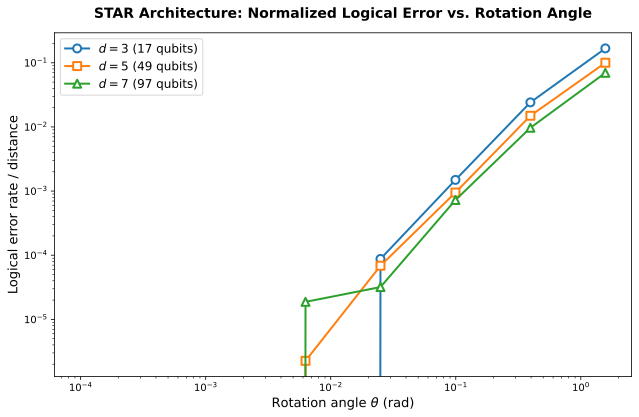

In [ ]:
import stim
import numpy as np
import matplotlib.pyplot as plt
from bloqade import tsim

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)

def run_tsim_star_benchmark():
    distances = [3, 5, 7]
    qubit_counts = {3: 17, 5: 49, 7: 97}
    
    angles_rad = np.logspace(-4, np.log10(np.pi/2), num=8)
    
    n_shots = 500_000 
    results = {d: [] for d in distances}

    for d in distances:
        print(f"\n=========================================")
        print(f" RUNNING TSIM SIMULATION: Distance {d}")
        
        file_path = f"assets/star_circuits/star_d={d}.stim"
        with open(file_path, "r") as f:
            base_stim_lines = f.read().split('\n')

        for angle_rad in angles_rad:
            logical_angle_in_pi = angle_rad / np.pi
            phys_angle_in_pi = physical_angle(logical_angle_in_pi, d)

            # PAULI APPROXIMATION HAC K:
            # Map the coherent rotation angles to probabilistic Pauli Z errors
            p_phys = np.sin((phys_angle_in_pi * np.pi) / 2) ** 2
            p_log = np.sin((logical_angle_in_pi * np.pi) / 2) ** 2

            modified_lines = []
            for line in base_stim_lines:
                clean_line = line.strip()
                
                match = re.match(r'^R_Z\([^)]+\)\s+(.*)$', clean_line)
                
                if match:
                    targets_str = match.group(1)
                    targets_list = targets_str.split()
                    
                    if len(targets_list) > 1:
                        # Replace Transversal Rotation with independent Z Errors
                        modified_lines.append(f"Z_ERROR({p_phys}) {targets_str}")
                    elif len(targets_list) == 1:
                        # Replace Logical Unrotation with independent Z Error
                        modified_lines.append(f"Z_ERROR({p_log}) {targets_str}")
                else:
                    modified_lines.append(clean_line)

            modified_stim_text = '\n'.join(modified_lines)

            temp_filename = f"temp_star_d{d}.stim"
            with open(temp_filename, "w") as f:
                f.write(modified_stim_text)

            c = Circuit.from_file(temp_filename)
            
            if os.path.exists(temp_filename):
                os.remove(temp_filename)

            sampler = c.compile_detector_sampler()
            detectors, observables = sampler.sample(shots=n_shots, separate_observables=True)

            # Post-selection Gadget
            bad_shots_mask = detectors.any(axis=1)
            clean_shots_mask = ~bad_shots_mask
            
            accepted_shots_count = np.sum(clean_shots_mask)

                
            surviving_logical_measurements = observables[clean_shots_mask]

            normalized_error = np.mean(surviving_logical_measurements) / d
            results[d].append(normalized_error)

            acc_rate = (accepted_shots_count / n_shots) * 100
            print(f"Angle: {angle_rad:.4e} rad | Acc: {acc_rate:.2f}% | Norm Error: {normalized_error:.4e}")


    plt.figure(figsize=(9, 6))
    markers = {3: 'o', 5: 's', 7: '^'}
    colors = {3: '#1f77b4', 5: '#ff7f0e', 7: '#2ca02c'}

    for d in distances:
        label = f"$d={d}$ ({qubit_counts[d]} qubits)"
        plt.loglog(angles_rad, results[d], marker=markers[d], color=colors[d], 
                   linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2, label=label)

    plt.xlabel('Rotation angle $\\theta$ (rad)', fontsize=13)
    plt.ylabel('Logical error rate / distance', fontsize=13)
    
    
    plt.legend(loc='upper left', fontsize=12)
    plt.title("STAR Architecture: Normalized Logical Error vs. Rotation Angle", fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_tsim_star_benchmark()

In [29]:
from tsim import Circuit 

c = Circuit.from_file("assets/star_circuits/star_d=3.stim")

c.diagram("timeslice-svg",height=1800)



In [25]:
c.diagram("pyzx", scale_horizontally=1.5)

Graph(1947 vertices, 2108 edges)

In [31]:
sampler = c.compile_detector_sampler()
detectors, observables = sampler.sample(shots=100_000, separate_observables=True)

In [33]:
# Find the bad shots. 
# .any(axis=1) checks horizontally across the 24 detectors for each shot. 
# If EVEN ONE detector is True, the whole shot is marked True (bad).
bad_shots_mask = detectors.any(axis=1)
clean_shots_mask = ~bad_shots_mask


surviving_logical_measurements = observables[clean_shots_mask]

logical_error_rate = np.mean(surviving_logical_measurements)